## Teste de performance dos Algoritmos de SSSP

In [223]:
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt

#### 1. Configurando parâmetros para rotina de testes

In [224]:
from graphs.graphs import Graph, dijkstra, generate_random_graph
from graphs.duan_et_al import sssp_duan_et_al


# Quantidade de grafos por configuração
num_graphs = 5

# Quantidade de vértices
num_vertices = (10, 100, 100)

# Densidade de arestas
edge_probabilities = (0.01, 0.1, 0.5)

# Algoritmos
algorithms = (dijkstra, sssp_duan_et_al)

#### 2. Executando rotina de testes

In [225]:
from random import seed
from time import perf_counter
import json

# Garantir reprodutibilidade
seed(42)

results = {}

for num_v in num_vertices:
    for edge_prob in edge_probabilities:
        for alg in algorithms:
            for _ in range(num_graphs):
                g = generate_random_graph(num_v, edge_prob)
                start_time = perf_counter()
                r = alg(g, 0)
                end_time = perf_counter()

                delta_time = end_time - start_time
                if results.get((num_v, edge_prob, alg.__name__)) is None:
                        results[(num_v, edge_prob, alg.__name__)] = []
                results[(num_v, edge_prob, alg.__name__)].append(delta_time)

dados_json = {
    str(k): v for k, v in results.items()
}

# Salvar os resultados em um arquivo JSON
with open('data/first_results.json', 'w') as f:
    json.dump(dados_json, f)

#### 3. Comparando resultados

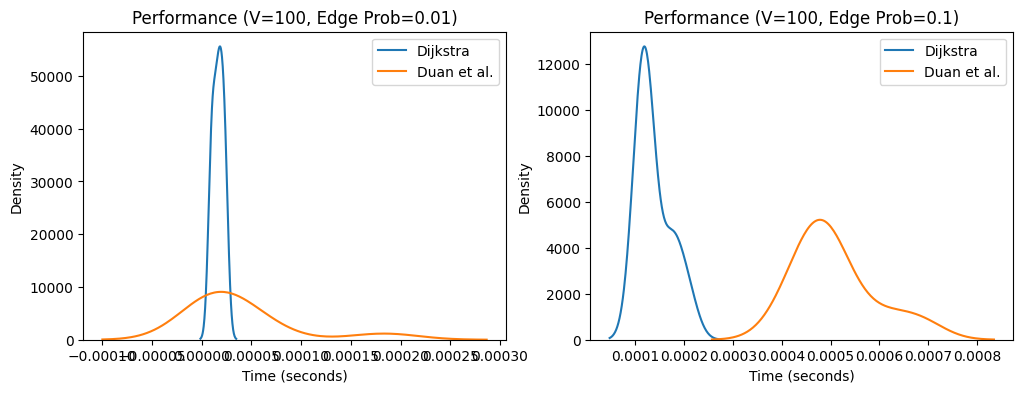

In [226]:
num_vertices_interesse = [100]
densidades_interesse = (0.01, 0.1)

# Utilizando subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for num_v in num_vertices_interesse:
    for i, edge_prob in enumerate(densidades_interesse):
        t_dijkstra = results[(num_v, edge_prob, 'dijkstra')]
        t_duan = results[(num_v, edge_prob, 'sssp_duan_et_al')]

        # Plotando kde
        sns.kdeplot(t_dijkstra, label='Dijkstra', ax=ax[i])
        sns.kdeplot(t_duan, label='Duan et al.', ax=ax[i])

        ax[i].set_title(f'Performance (V={num_v}, Edge Prob={edge_prob})')
        ax[i].set_xlabel('Time (seconds)')
        ax[i].set_ylabel('Density')
        ax[i].legend()

Antes de regredir a apenas os dois gráficos, testou-se todas as configurações para experimentação, e, para o grafo esparso, o algoritmo de Duan et al se mostrou mais eficiente.

#### 4. Executando rotina mais robusta para grafos maiores esparsos

In [227]:
qt_vertices = (100, 100)
probabilidade_arestas = (0.01, 0.05)
qt_grafos = 10

for num_v in qt_vertices:
    for edge_prob in probabilidade_arestas:
        for algorithm in algorithms:
            for _ in range(qt_grafos):
                g = generate_random_graph(num_v, edge_prob)
                start_time = perf_counter()
                r = algorithm(g, 0)
                end_time = perf_counter()

                delta_time = end_time - start_time
                if results.get((num_v, edge_prob, algorithm.__name__)) is None:
                        results[(num_v, edge_prob, algorithm.__name__)] = []
                results[(num_v, edge_prob, algorithm.__name__)].append(delta_time)

dados_json = {
    str(k): v for k, v in results.items()
}

# Salvar os resultados em um arquivo JSON
with open('data/second_results.json', 'w') as f:
    json.dump(dados_json, f)

Após a execução da rotina, plotando os dados

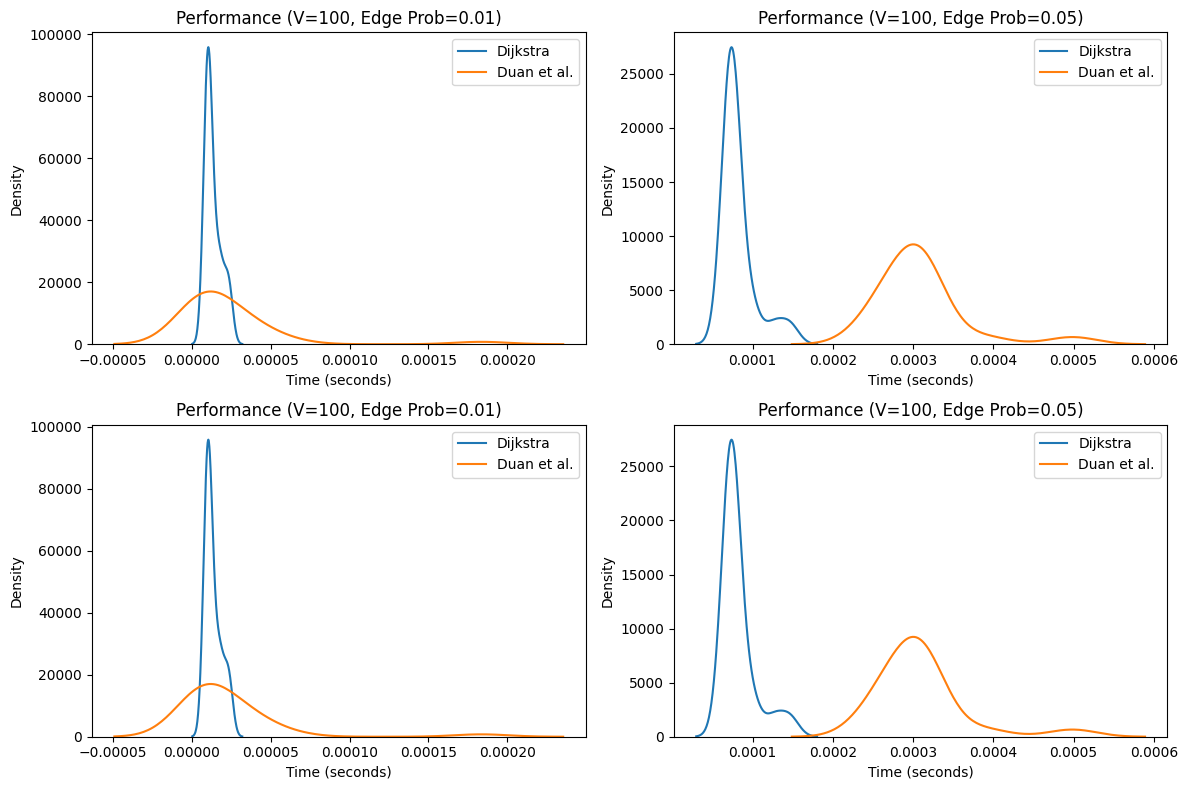

In [228]:
# Utilizando um subplot de 4 posicões
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax = ax.flatten()

i = 0

for num_v in qt_vertices:
    for edge_prob in probabilidade_arestas:
        t_dijkstra = results[(num_v, edge_prob, 'dijkstra')]
        t_duan = results[(num_v, edge_prob, 'sssp_duan_et_al')]
       
        # Plotando kde
        sns.kdeplot(t_dijkstra, label='Dijkstra', ax=ax[i])
        sns.kdeplot(t_duan, label='Duan et al.', ax=ax[i])

        ax[i].set_title(f'Performance (V={num_v}, Edge Prob={edge_prob})')
        ax[i].set_xlabel('Time (seconds)')
        ax[i].set_ylabel('Density')
        ax[i].legend()
        i += 1

plt.tight_layout()
plt.show()